In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from minimos_cuadrados import minimos_cuadrados
from minimos_cuadrado_vid import minimos_cuadrados_vid
from spline_cubico_natural_vid import spline_cubico_natural_vid

In [2]:
# Cargar el dataframe con las variables que se van a utilizar
df = pd.read_csv(r"asthma_disease_data.csv")
pd.set_option('display.max_rows', None)
cols = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies" , "Diagnosis"
]
# Vuelve a cargar el dataframe con las variables seleccionadas
df = pd.read_csv("asthma_disease_data.csv", usecols=cols)
# Elimina las filas con valores nulos
df = df.dropna()
print(df)

      Age  Gender  Smoking  PhysicalActivity  DietQuality  PollutionExposure  \
0      63       0        0          0.894448     5.488696           7.388481   
1      26       1        0          5.897329     6.341014           1.969838   
2      57       0        0          6.739367     9.196237           1.460593   
3      40       1        0          1.404503     5.826532           0.581905   
4      61       0        0          4.604493     3.127048           0.980875   
5      21       0        0          0.470044     1.759118           1.711446   
6      45       1        1          9.371784     7.030507           7.664306   
7      26       0        1          8.344096     1.626484           6.939046   
8      49       1        0          2.690256     3.920034           3.180421   
9      45       1        0          2.895720     2.607700           1.711722   
10     27       0        0          3.900003     1.748193           1.546419   
11     62       1        0          6.63

In [3]:
# Muestra las dimensiones del dataframe
df.shape

(2392, 11)

In [4]:
# Muestra la información detallada del dataframe para verificar los tipos de datos y si existen valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2392 non-null   int64  
 1   Gender               2392 non-null   int64  
 2   Smoking              2392 non-null   int64  
 3   PhysicalActivity     2392 non-null   float64
 4   DietQuality          2392 non-null   float64
 5   PollutionExposure    2392 non-null   float64
 6   PollenExposure       2392 non-null   float64
 7   DustExposure         2392 non-null   float64
 8   FamilyHistoryAsthma  2392 non-null   int64  
 9   HistoryOfAllergies   2392 non-null   int64  
 10  Diagnosis            2392 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 205.7 KB


<Figure size 1000x600 with 0 Axes>

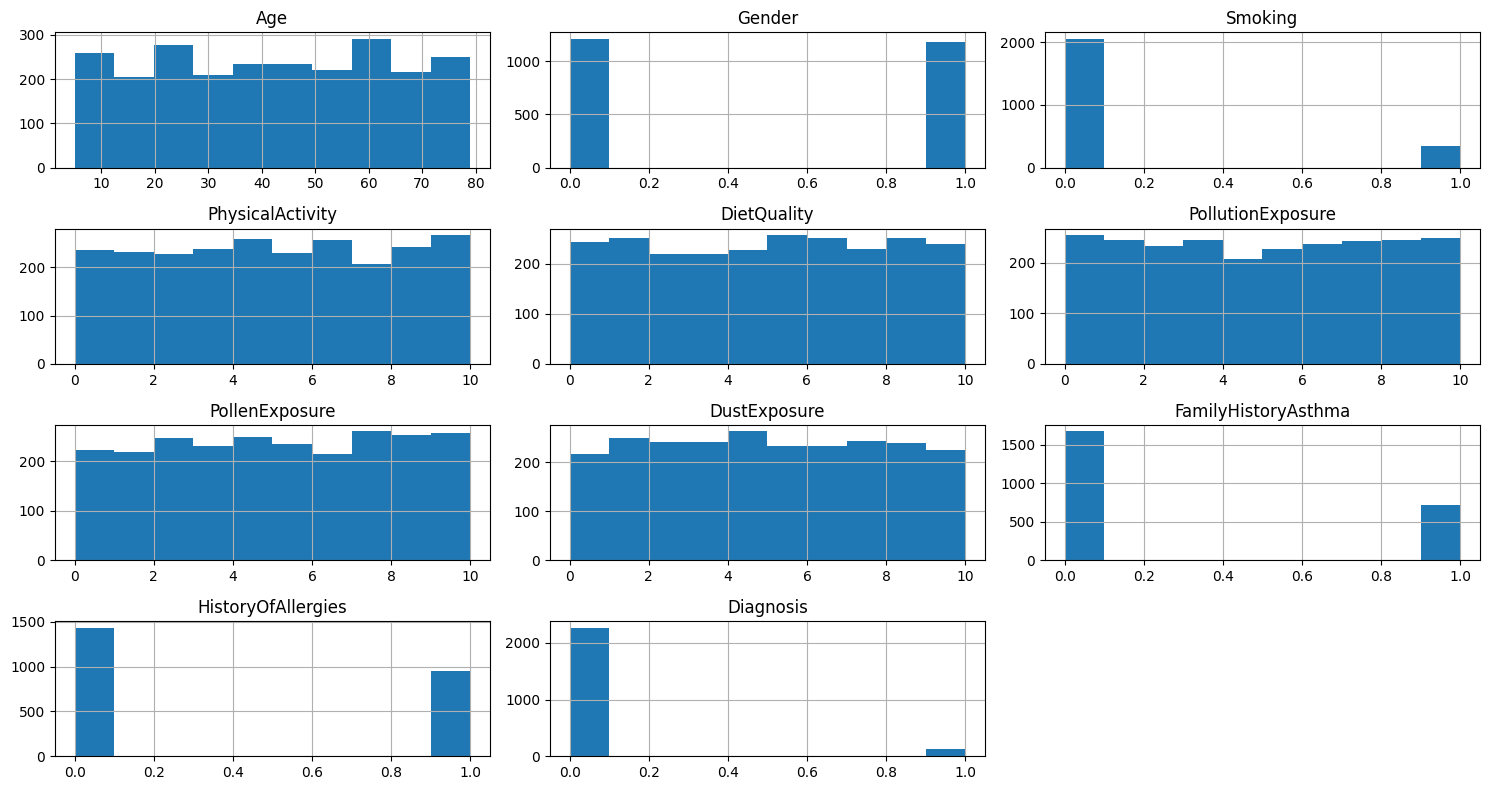

In [5]:
# Visualización de la distribución de los datos
plt.figure(figsize=(10, 6))
df.describe()
df.hist(figsize=(15, 8))
plt.tight_layout()
plt.show()

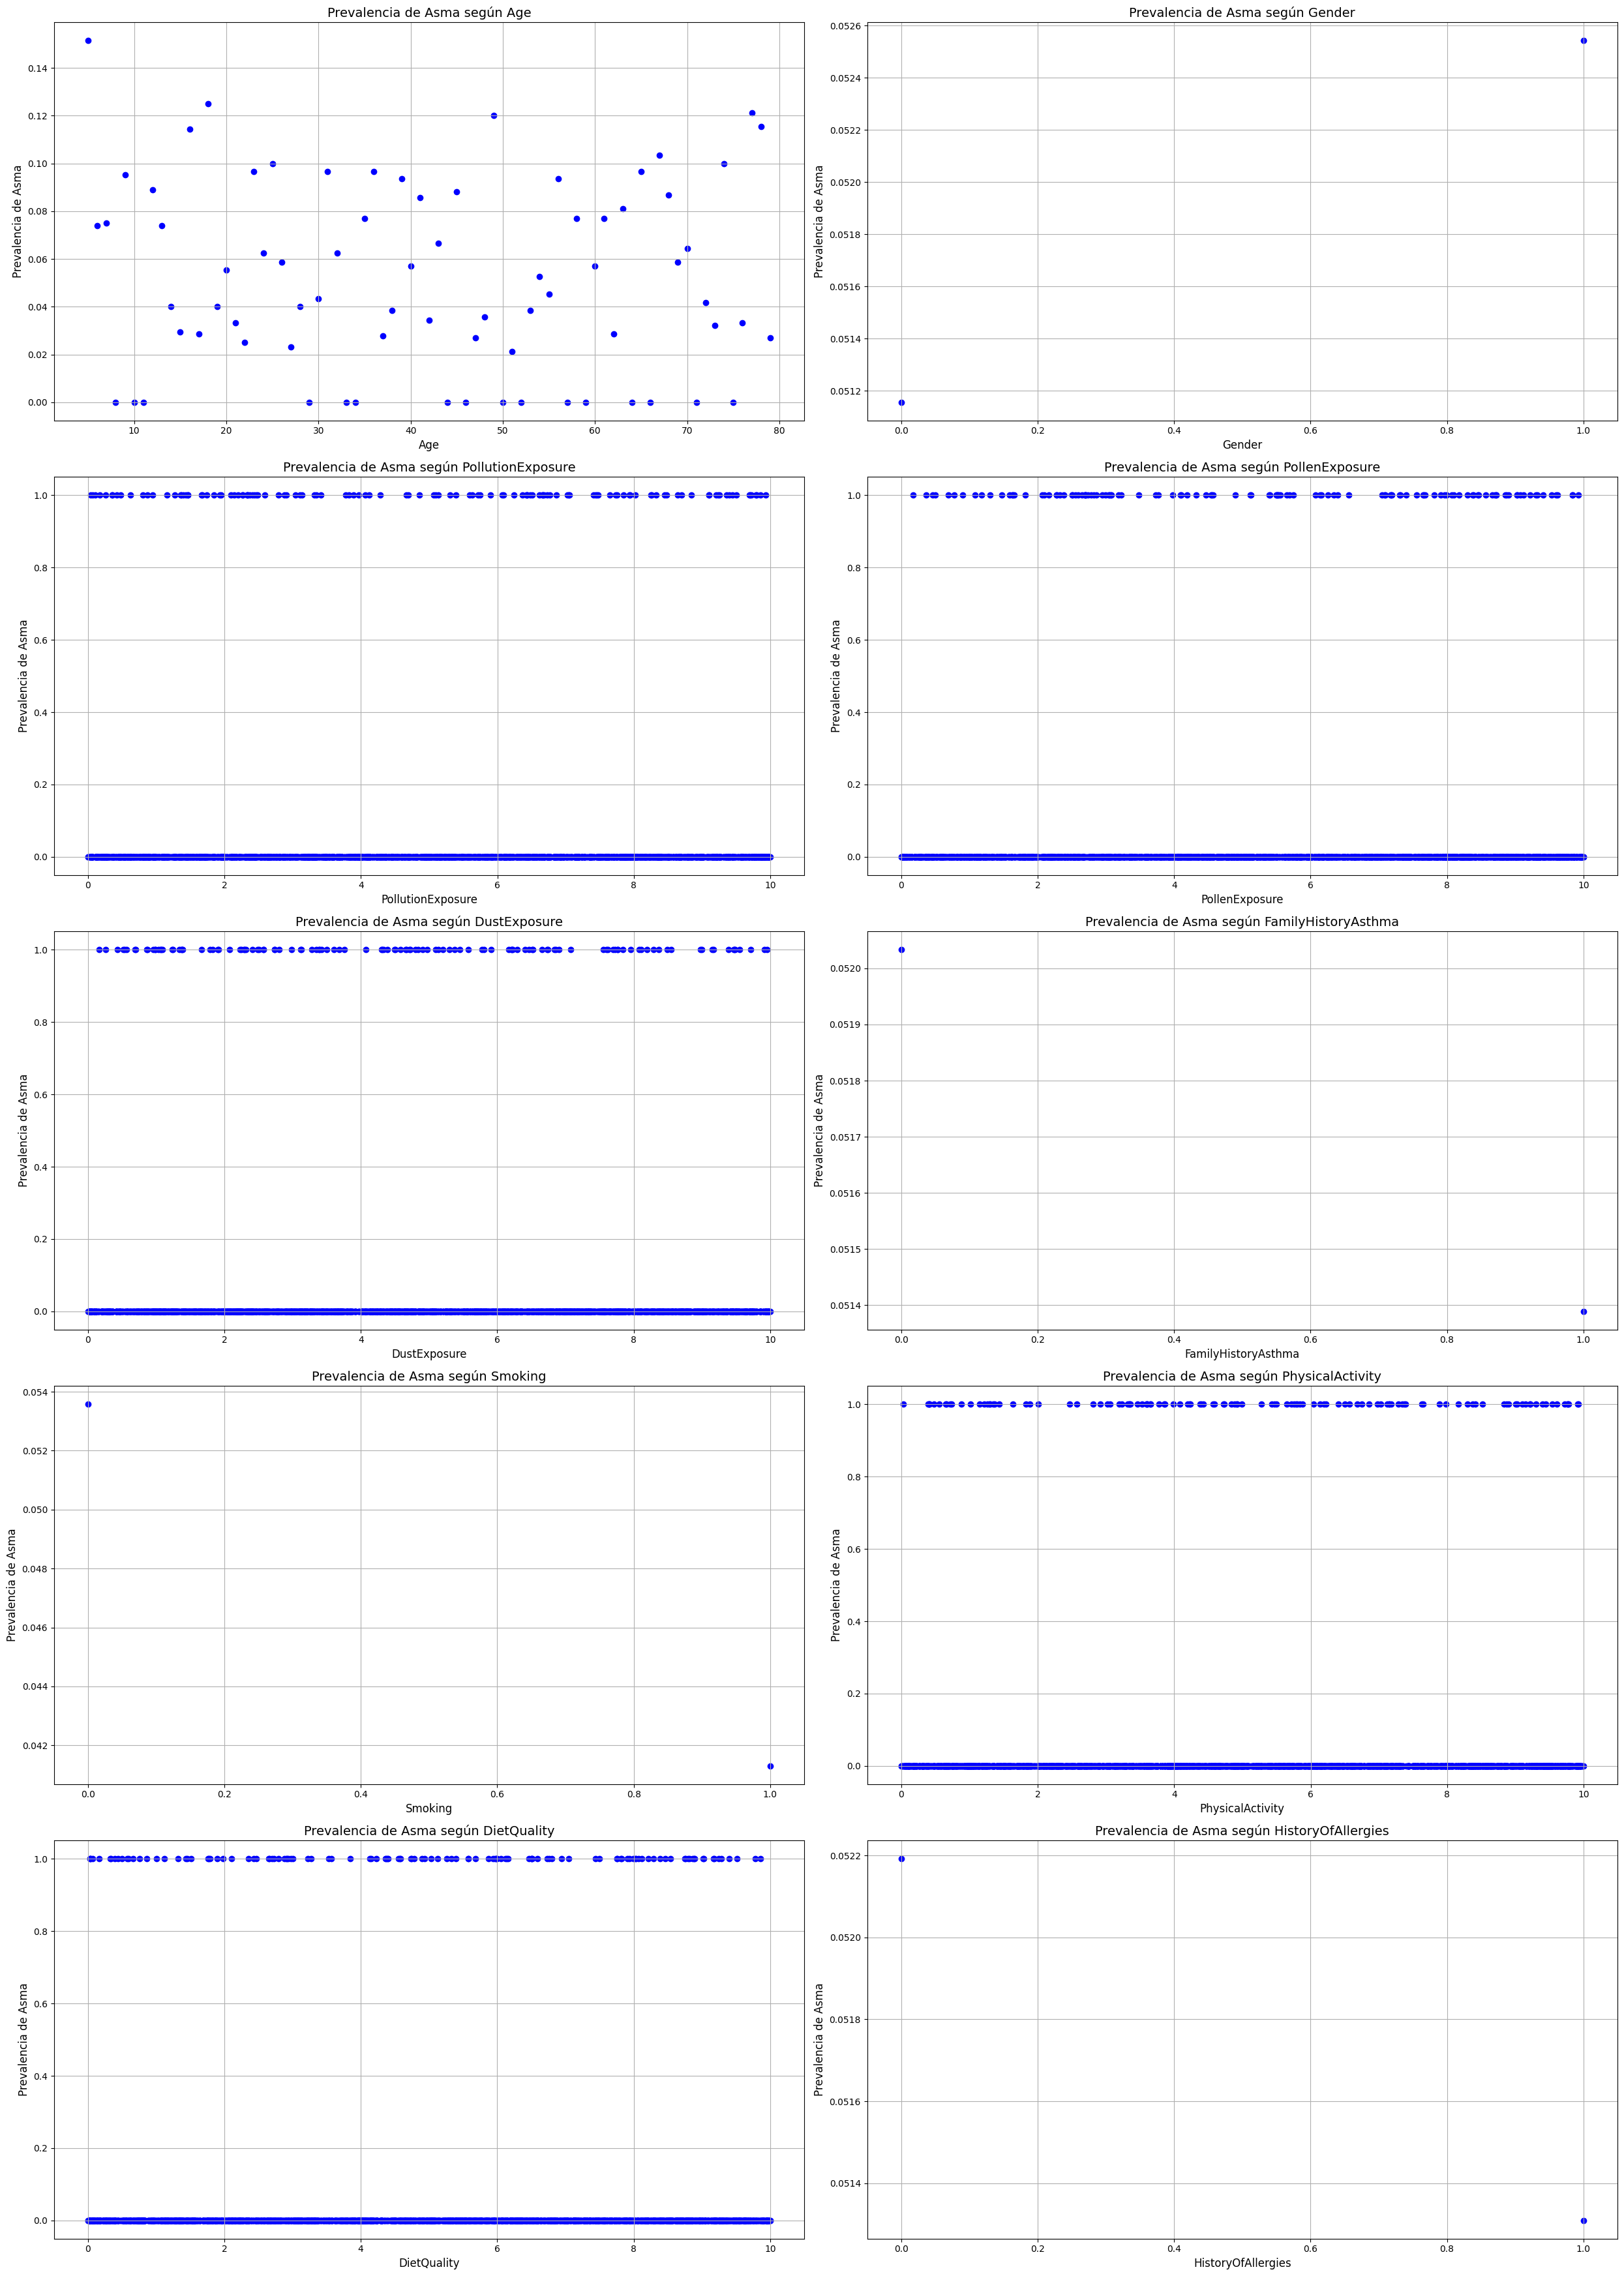

In [6]:
#Gráfica de Prevalencia del Asma (Diagnosis) vs Variables
df = df[cols].dropna()

# Variables independientes para analizar
variables = [
    "Age", "Gender", "PollutionExposure", "PollenExposure", "DustExposure",
    "FamilyHistoryAsthma", "Smoking", "PhysicalActivity",
    "DietQuality", "HistoryOfAllergies"
]

fig, axes = plt.subplots(5, 2, figsize=(25, 35))
axes = axes.flatten()

# Generación de gráficas individuales para cada relación
for i, var in enumerate(variables):
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    x = prevalencia.index
    y = prevalencia.values

    axes[i].scatter(x, y, color='blue')
    axes[i].set_title(f'Prevalencia de Asma según {var}', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('Prevalencia de Asma', fontsize=12)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Grupo de Edad')

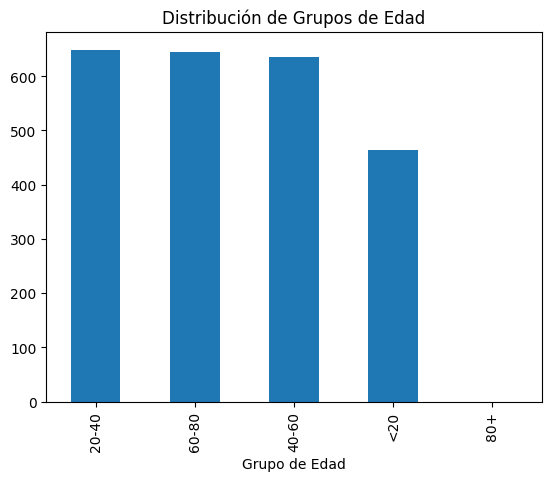

In [7]:
# Agrupación de edades en grupos
max_edad = max(80, df['Age'].max()) + 1
rangos = [0, 20, 40, 60, 80, max_edad]
labels = ['<20', '20‑40', '40‑60', '60‑80', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=rangos, labels=labels, right=False)
df['AgeGroup'].value_counts().plot(kind='bar', title='Distribución de Grupos de Edad')
plt.xlabel('Grupo de Edad')

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


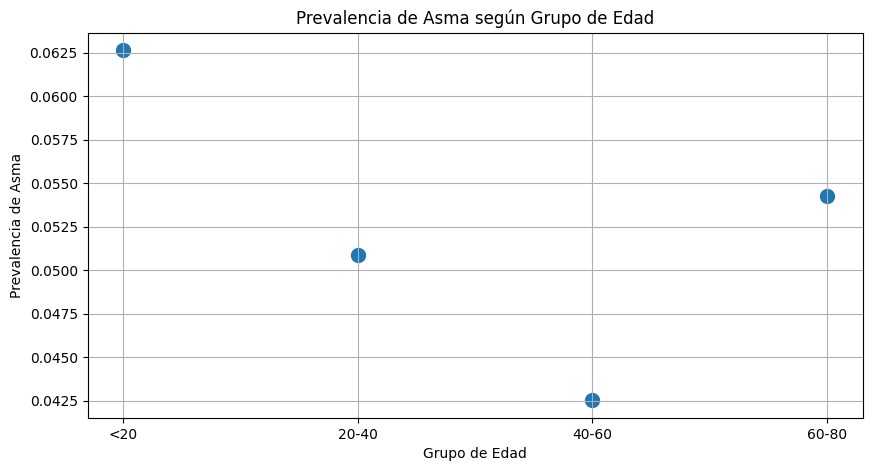

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


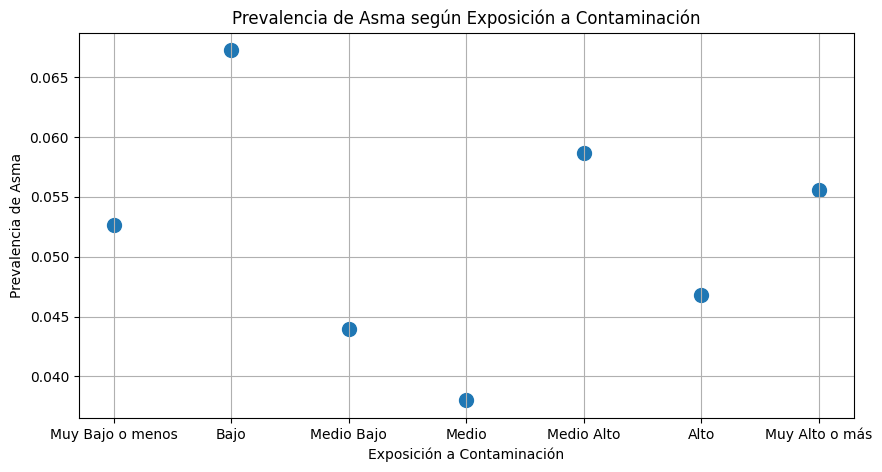

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


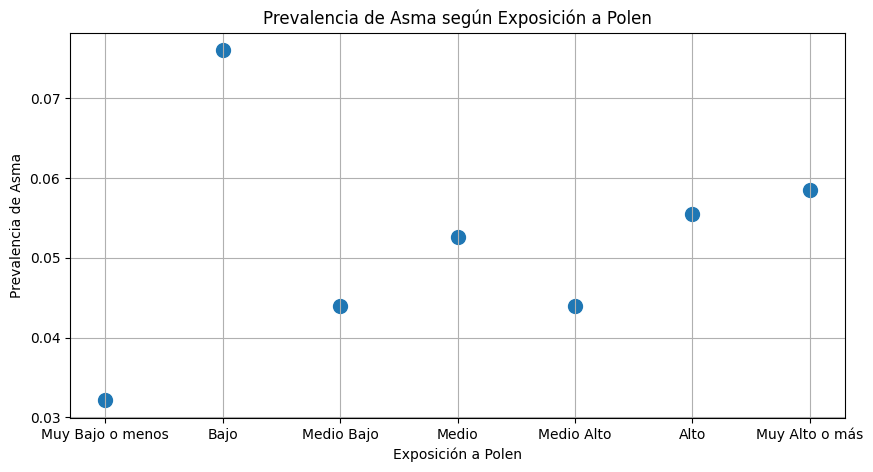

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


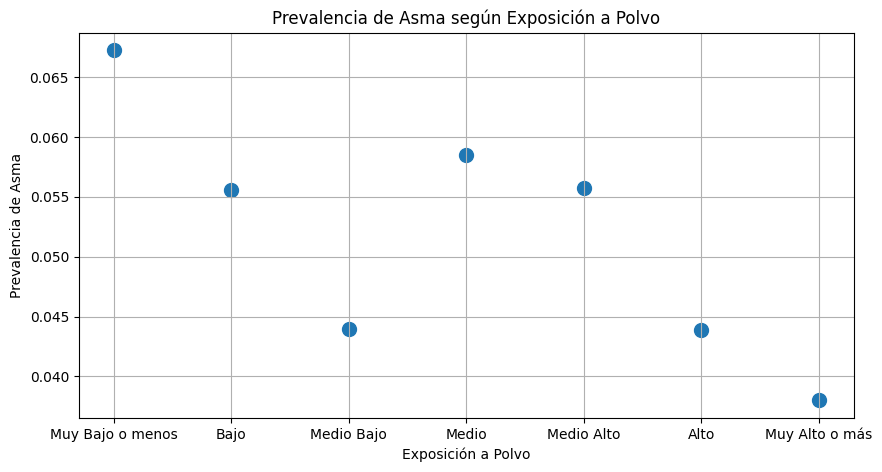

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


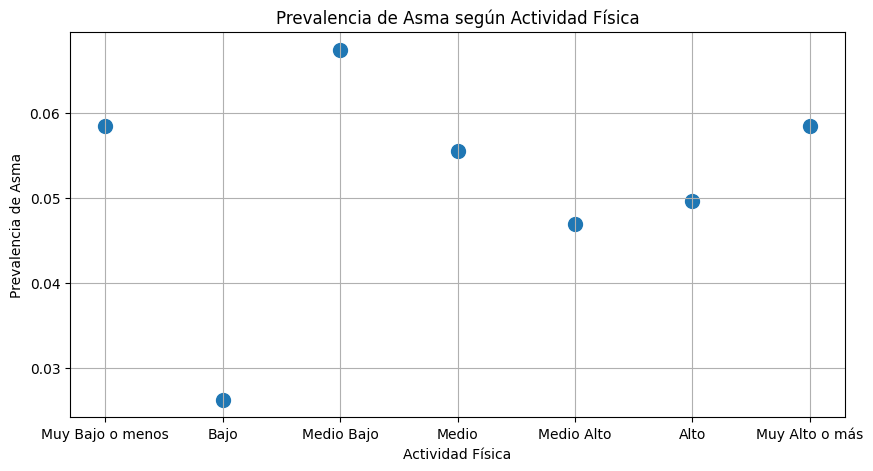

/tmp/ipykernel_8037/1708734768.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prevalencia = df.groupby(var)['Diagnosis'].mean()


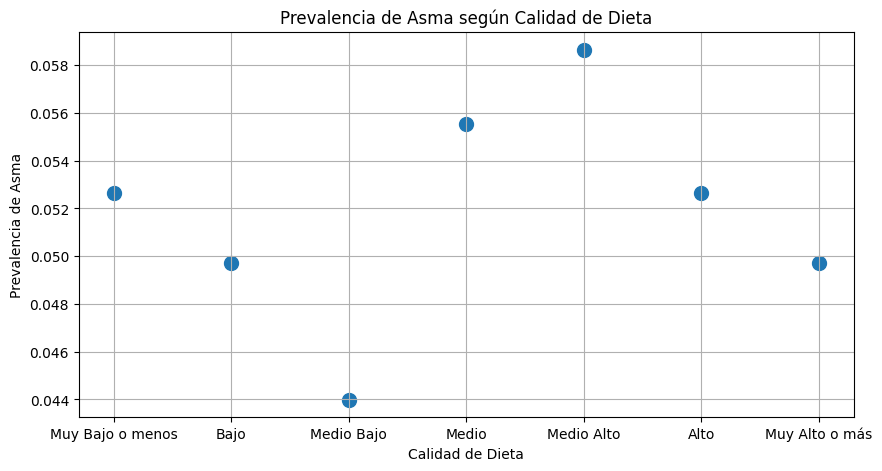

In [9]:
#Etiquetas para la distribucion en grupos en las demas variables.
etiquetas = ['Muy Bajo o menos', 'Bajo', 'Medio Bajo', 'Medio', 'Medio Alto', 'Alto', 'Muy Alto o más']

for var in ['PollutionExposure', 'PollenExposure', 'DustExposure', 'PhysicalActivity', 'DietQuality']:
    try:
        df[var + 'Group'] = pd.qcut(df[var], q=7, labels=etiquetas, duplicates='drop')
    except ValueError:
        df[var + 'Group'] = pd.cut(df[var], bins=7, labels=etiquetas, include_lowest=True)

agrupadas = {
    'AgeGroup': 'Grupo de Edad',
    'PollutionExposureGroup': 'Exposición a Contaminación',
    'PollenExposureGroup': 'Exposición a Polen',
    'DustExposureGroup': 'Exposición a Polvo',
    'PhysicalActivityGroup': 'Actividad Física',
    'DietQualityGroup': 'Calidad de Dieta'
}

#Visualización de Prevalencia de Asma vs variables en grupos (de ser necesario)
for var, titulo in agrupadas.items():
    prevalencia = df.groupby(var)['Diagnosis'].mean()
    plt.figure(figsize=(10,5))
    plt.scatter(prevalencia.index.astype(str), prevalencia.values, s=100)
    plt.title(f'Prevalencia de Asma según {titulo}')
    plt.xlabel(titulo)
    plt.ylabel('Prevalencia de Asma')
    plt.grid(True)
    plt.show()

In [23]:
# Ver los límites (mínimos, máximos) y cantidad de datos en cada grupo para todas las variables agrupadas. 

for var in agrupadas:
    print(f"\n{'-'*100}\nDistribución de grupos para: {var}")
    # Muestra las etiquetas y los cortes usados por pandas
    for label in df[var].cat.categories:
        valores = df.loc[df[var] == label, var.replace('Group', '')]  # extrae los valores reales
        print(f"{label}: {valores.min()} a {valores.max()} (N={valores.count()})")



----------------------------------------------------------------------------------------------------
Distribución de grupos para: AgeGroup
<20: 5 a 19 (N=463)
20‑40: 20 a 39 (N=649)
40‑60: 40 a 59 (N=635)
60‑80: 60 a 79 (N=645)
80+: nan a nan (N=0)

----------------------------------------------------------------------------------------------------
Distribución de grupos para: PollutionExposureGroup
Muy Bajo o menos: 0.0010215049107153 a 1.397764480679351 (N=342)
Bajo: 1.3984915589261826 a 2.77618270746036 (N=342)
Medio Bajo: 2.78913171216884 a 4.224030177517512 (N=341)
Medio: 4.224505799731445 a 5.782557722587409 (N=342)
Medio Alto: 5.782724380118961 a 7.271006256389818 (N=341)
Alto: 7.271013351994197 a 8.614211318542397 (N=342)
Muy Alto o más: 8.61497773419407 a 9.998964331499586 (N=342)

----------------------------------------------------------------------------------------------------
Distribución de grupos para: PollenExposureGroup
Muy Bajo o menos: 0.0006590280421692 a 1.514786

<center><h2>Selección del método tras las la visualización de las gráficas de prevalencia vs variables independientes<h2></center>

| **Variable**                      | **Método seleccionado** | **Explicación**                                                                               |
| --------------------------------- | ----------------------- | --------------------------------------------------------------------------------------------- |
| **Edad** *(AgeGroup)*             | **Splines cúbicos**     | Relación no lineal entre grupos, con posibles picos en ciertos rangos.                        |
| **Género**                        | **Mínimos cuadrados**   | Sólo hay dos categorías, femenino o masculino.                                                |
| **Contaminación** *(agrupada)*    | **Splines cúbicos**     | La relación no es lineal ni monótona en las 7 etiquetas.                                      |
| **Exposición Pólen** *(agrupada)* | **Mínimos cuadrados**   | Las fluctuaciones son suaves, lo que permite una aproximación lineal.                         |
| **Exposición Polvo** *(agrupada)* | **Mínimos cuadrados**   | Se observa una relación visualmente lineal entre los grupos.                                  |
| **Historia Familiar**             | **Mínimos cuadrados**   | Dos categorías (sí/no), con una comparación directa.                                          |
| **Tabaquismo**                    | **Mínimos cuadrados**   | Dos categorías (sí/no), de forma lineal.                                                      |
| **Actividad Física** *(agrupada)* | **Mínimos cuadrados**   | La relación es ordenada y carece de grandes curvas, lo que permite un ajuste lineal adecuado. |
| **Calidad Dieta** *(agrupada)*    | **Splines cúbicos**     | Se presentan cambios no lineales en los grupos intermedios.                                   |
| **Historial Alergias**            | **Mínimos cuadrados**   | Dos categorías, con un ajuste directo y sencillo.                                             |


In [ ]:
# Agrupa la proporcion de diagnóstico por edad
# Esto asume que 'Diagnosis' es una columna binaria donde 1 indica diagnóstico positivo y 0 negativo.
prevalencia_edad = df.groupby('Age')['Diagnosis'].mean()
x = prevalencia_edad.index.tolist()
y = prevalencia_edad.values.tolist()
print(minimos_cuadrados(x, y, 4))

In [ ]:
# Agrupa la proporcion de diagnóstico por genero
prevalencia_genero = df.groupby('Gender')['Diagnosis'].mean()
x = prevalencia_genero.index.tolist()
y = prevalencia_genero.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))

In [ ]:
# Agrupa la proporcion de diagnóstico por consumo de tabaco
prevalencia_fumadores = df.groupby('Smoking')['Diagnosis'].mean()
x = prevalencia_fumadores.index.tolist()    
y = prevalencia_fumadores.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados(x, y, 4))

In [ ]:
# Agrupa la proporcion de diagnóstico por actividad física
prevalencia_act_fisica = df.groupby('PhysicalActivity')['Diagnosis'].mean()
x = prevalencia_act_fisica.index.tolist()
y = prevalencia_act_fisica.values.tolist()
print(minimos_cuadrados(x, y, 4))

In [ ]:
# Agrupa la proporcion de diagnóstico por calidad de la dieta
prevalencia_calidad_dieta = df.groupby('DietQuality')['Diagnosis'].mean()
x = prevalencia_calidad_dieta.index.tolist()  
y = prevalencia_calidad_dieta.values.tolist()
print(minimos_cuadrados(x, y, 4))     

In [ ]:
# La agrupación con la proporción de diagnóstico con la contaminación ambiental (polución)
prevalencia_polucion = df.groupby('PollutionExposure')['Diagnosis'].mean()
x = prevalencia_polucion.index.tolist()
y = prevalencia_polucion.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))

In [ ]:
# La agrupación con la proporción de diagnóstico con la exposición al polen.
prevalencia_polen = df.groupby('PollenExposure')['Diagnosis'].mean()
x = prevalencia_polen.index.tolist()    
y = prevalencia_polen.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))

In [ ]:
# La agrupación con la proporción de diagnóstico con la exposición al polvo.
prevalencia_polvo = df.groupby('DustExposure')['Diagnosis'].mean()
x = prevalencia_polvo.index.tolist()
y = prevalencia_polvo.values.tolist()
print(minimos_cuadrados_vid(x, y, 4))

In [ ]:
# La agrupación con la proporción de diagnóstico con el historial familar con respecto al Asma.
prevalencia_asma = df.groupby('FamilyHistoryAsthma')['Diagnosis'].mean()
x = prevalencia_asma.index.tolist()
y = prevalencia_asma.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))

In [ ]:
# La agrupación con la proporción de diagnóstico con el historial de alergias del paciente.
prevalencia_genero = df.groupby('HistoryOfAllergies')['Diagnosis'].mean()
x = prevalencia_genero.index.tolist()
y = prevalencia_genero.values.tolist()
print(spline_cubico_natural_vid(x, y, 4))
print(minimos_cuadrados_vid(x, y, 4))